## Part 1 - Data / EDA / Feature Engineering
#### **Target:** CANCELLED (binary: 1 = cancelled, 0 = operated)

In [5]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [6]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

os.makedirs("EDA", exist_ok=True)

CSV_PATH = "Data/flights_sample_3m.csv"

In [7]:
# Load data
df = pd.read_csv(CSV_PATH, low_memory=False)

# Parse date and extract YEAR / MONTH / DAY_OF_WEEK upfront
df["FL_DATE"]     = pd.to_datetime(df["FL_DATE"], errors="coerce")
df["YEAR"]        = df["FL_DATE"].dt.year
df["MONTH"]       = df["FL_DATE"].dt.month
df["DAY_OF_WEEK"] = df["FL_DATE"].dt.dayofweek

# Coerce CANCELLED to int
df["CANCELLED"] = pd.to_numeric(df["CANCELLED"], errors="coerce")
df = df.dropna(subset=["CANCELLED"])
df["CANCELLED"] = df["CANCELLED"].astype(int)

print(f"Shape: {df.shape}")
print(f"Years: {sorted(df['YEAR'].unique())}")
print(f"Cancel rate: {df['CANCELLED'].mean()*100:.2f}%")
df.head(3)

Shape: (3000000, 35)
Years: [2019, 2020, 2021, 2022, 2023]
Cancel rate: 2.64%


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,YEAR,MONTH,DAY_OF_WEEK
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,153.0,1065.0,NaN,NaN,NaN,NaN,NaN,2019,1,2
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,189.0,1399.0,NaN,NaN,NaN,NaN,NaN,2022,11,5
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,87.0,680.0,NaN,NaN,NaN,NaN,NaN,2022,7,4


In [9]:
# Data cleaning

# Remove diverted flights
df["DIVERTED"] = pd.to_numeric(df["DIVERTED"], errors="coerce").fillna(0).astype(int)
n_before = len(df)
df = df[df["DIVERTED"] != 1].copy()
print(f"Removed {n_before - len(df):,} diverted rows")

LEAKAGE_COLS = [
    "DEP_TIME", "DEP_DELAY",
    "TAXI_OUT", "WHEELS_OFF", "WHEELS_ON", "TAXI_IN",
    "ARR_TIME", "ARR_DELAY",
    "ELAPSED_TIME", "AIR_TIME",
    "DELAY_DUE_CARRIER", "DELAY_DUE_WEATHER", "DELAY_DUE_NAS",
    "DELAY_DUE_SECURITY", "DELAY_DUE_LATE_AIRCRAFT",
    "CANCELLATION_CODE",
]

df[[c for c in LEAKAGE_COLS if c in df.columns]] = \
    df[[c for c in LEAKAGE_COLS if c in df.columns]].fillna(0)

# Drop rows missing key pre-flight fields
required = ["AIRLINE_CODE", "ORIGIN", "DEST", "CRS_DEP_TIME", "DISTANCE"]
df = df.dropna(subset=required)

# Cast numerics
for col in ["CRS_DEP_TIME", "CRS_ARR_TIME", "DISTANCE", "CRS_ELAPSED_TIME"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=["CRS_DEP_TIME", "DISTANCE"])

# Standardize string columns
for col in ["AIRLINE_CODE", "ORIGIN", "DEST"]:
    df[col] = df[col].astype(str).str.strip().str.upper()

print(f"(After cleaning) shape: {df.shape}; cancel rate: {df['CANCELLED'].mean()*100:.2f}%")

Removed 7,056 diverted rows
(After cleaning) shape: (2992944, 43); cancel rate: 2.64%


In [10]:
# ==========================================
# Feature engineering
# ==========================================

# Time features from scheduled departure
df["DEP_HOUR"] = (df["CRS_DEP_TIME"] // 100).astype(int)
df["DEP_MIN"]  = (df["CRS_DEP_TIME"] %  100).astype(int)

def hour_to_period(h):
    if   h < 6:  return "red_eye"
    elif h < 12: return "morning"
    elif h < 17: return "afternoon"
    elif h < 21: return "evening"
    else:        return "night"

df["DEP_PERIOD"] = df["DEP_HOUR"].apply(hour_to_period)

# Calendar features
df["IS_WEEKEND"]        = df["DAY_OF_WEEK"].isin([5, 6]).astype(int)
df["IS_HOLIDAY_SEASON"] = df["MONTH"].isin([11, 12, 1]).astype(int)
df["IS_SUMMER_PEAK"]    = df["MONTH"].isin([6, 7, 8]).astype(int)

# COVID anomaly flag
df["IS_COVID_YEAR"] = (df["YEAR"] == 2020).astype(int)

# Combine Origin and Destination for Route feature
df["ROUTE"] = df["ORIGIN"] + "_" + df["DEST"]


# Drop leakage columns (Make sure LEAKAGE_COLS is defined as a list earlier)
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns])

print(f"✅ Feature Engineering Complete!")
print(f"Features: {df.shape[1]}; Rows: {df.shape[0]:,}")
print("Columns:", list(df.columns))

✅ Feature Engineering Complete!
Features: 27; Rows: 2,992,944
Columns: ['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE', 'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY', 'CRS_DEP_TIME', 'CRS_ARR_TIME', 'CANCELLED', 'DIVERTED', 'CRS_ELAPSED_TIME', 'DISTANCE', 'YEAR', 'MONTH', 'DAY_OF_WEEK', 'DEP_HOUR', 'DEP_MIN', 'DEP_PERIOD', 'IS_WEEKEND', 'IS_HOLIDAY_SEASON', 'IS_SUMMER_PEAK', 'IS_COVID_YEAR', 'ROUTE']


In [11]:
# Train / Test split (temporal)
train = df[df["YEAR"] < 2023].copy()
test  = df[df["YEAR"] == 2023].copy()

print(f"Train: {len(train):>10,} rows  ({train['YEAR'].min()}–{train['YEAR'].max()})  "
      f"cancel rate: {train['CANCELLED'].mean()*100:.2f}%")
print(f"Test:  {len(test):>10,} rows  (2023)                    "
      f"cancel rate: {test['CANCELLED'].mean()*100:.2f}%")

SAVE_DIR = "/content/drive/MyDrive/MLOps/"

train.to_csv("train.csv", index=False)
test.to_csv("test.csv",   index=False)

Train:  2,530,721 rows  (2019–2022)  cancel rate: 2.82%
Test:     462,223 rows  (2023)                    cancel rate: 1.69%


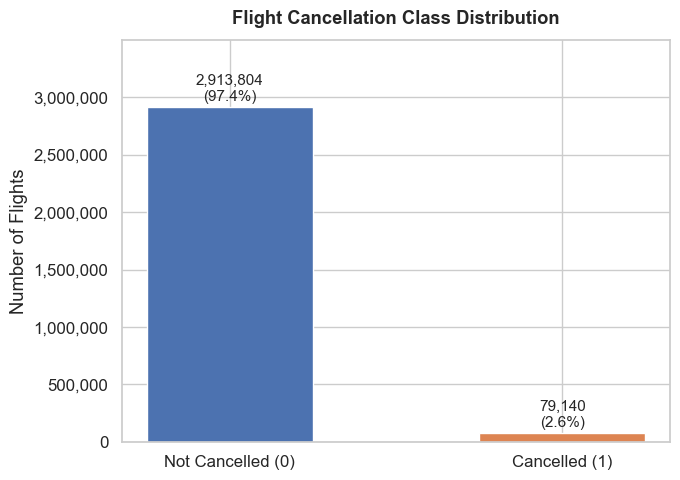

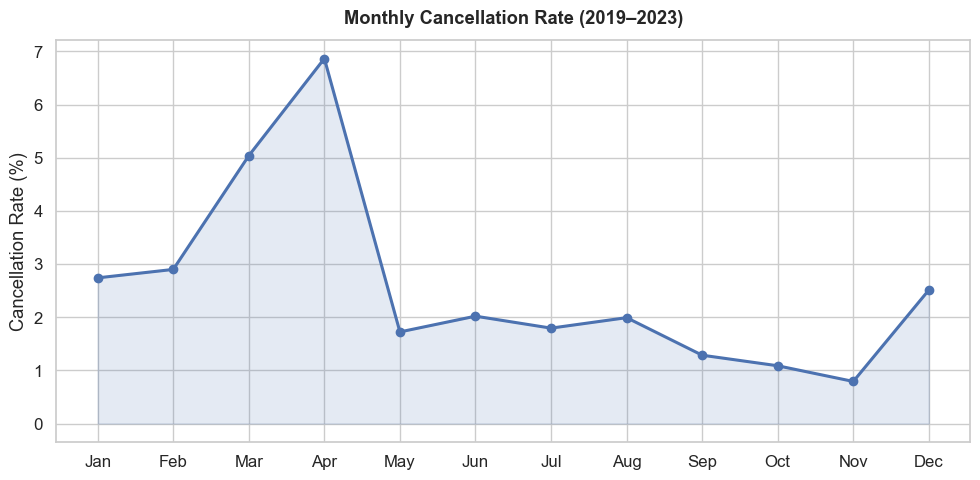

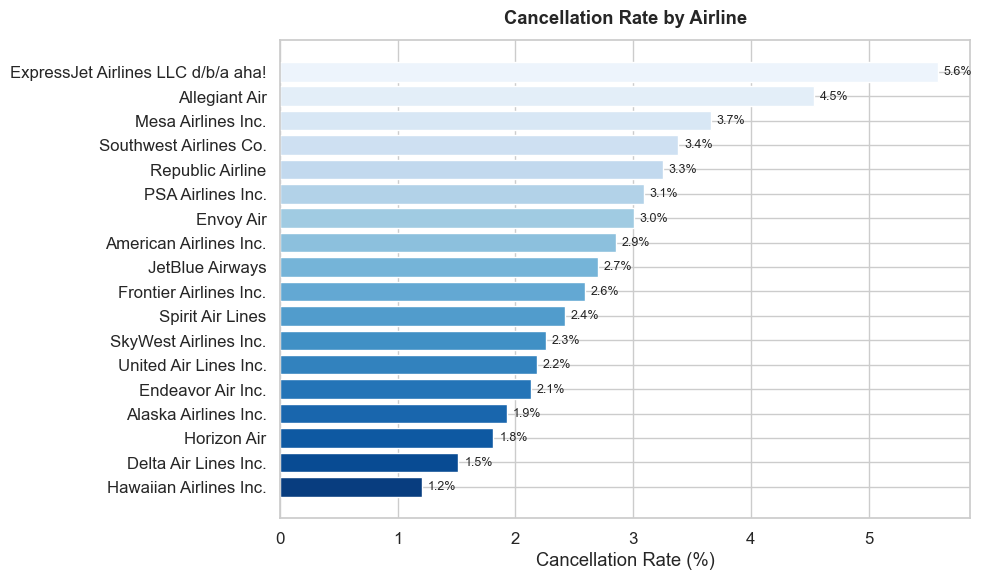

In [7]:
# EDA
# Class distribution
counts = df["CANCELLED"].value_counts().sort_index()
labels = ["Not Cancelled (0)", "Cancelled (1)"]
pcts   = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, counts, color=["#4C72B0", "#DD8452"], width=0.5, edgecolor="white")
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + counts.max()*0.01,
            f"{bar.get_height():,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=11)
ax.set_title("Flight Cancellation Class Distribution", fontweight="bold", pad=12)
ax.set_ylabel("Number of Flights")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, counts.max() * 1.2)
plt.tight_layout()
plt.show()

# Monthly cancellation rate
monthly = df.groupby("MONTH")["CANCELLED"].mean().mul(100)
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly.index, monthly.values, marker="o", linewidth=2.2, color="#4C72B0")
ax.fill_between(monthly.index, monthly.values, alpha=0.15, color="#4C72B0")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title("Monthly Cancellation Rate (2019–2023)", fontweight="bold", pad=12)
ax.set_ylabel("Cancellation Rate (%)")
plt.tight_layout()
plt.show()

# Cancellation rate by airline carrier
stats = (df.groupby("AIRLINE_CODE")["CANCELLED"]
           .agg(cancel_rate="mean", total="count")
           .query("total >= 1000")
           .assign(cancel_rate=lambda x: x["cancel_rate"] * 100)
           .sort_values("cancel_rate"))

# Merge in full airline name for readability
airline_map = dict(zip(df["AIRLINE_CODE"], df["AIRLINE"]))
stats["airline_name"] = [airline_map.get(code, code) for code in stats.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(stats["airline_name"], stats["cancel_rate"],
               color=sns.color_palette("Blues_r", len(stats)), edgecolor="white")
for bar in bars:
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1f}%", va="center", fontsize=9)
ax.set_title("Cancellation Rate by Airline", fontweight="bold", pad=12)
ax.set_xlabel("Cancellation Rate (%)")
plt.tight_layout()
plt.show()

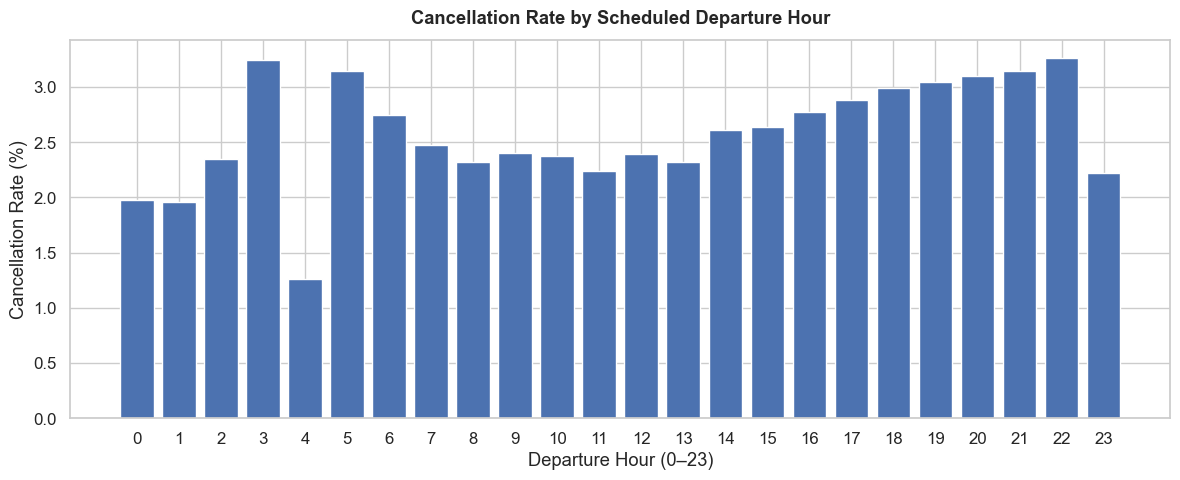

In [8]:
# Cancel rate by departure hour
hourly = df.groupby("DEP_HOUR")["CANCELLED"].mean().mul(100)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(hourly.index, hourly.values, color="#4C72B0", edgecolor="white")
ax.set_title("Cancellation Rate by Scheduled Departure Hour", fontweight="bold", pad=12)
ax.set_xlabel("Departure Hour (0–23)")
ax.set_ylabel("Cancellation Rate (%)")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

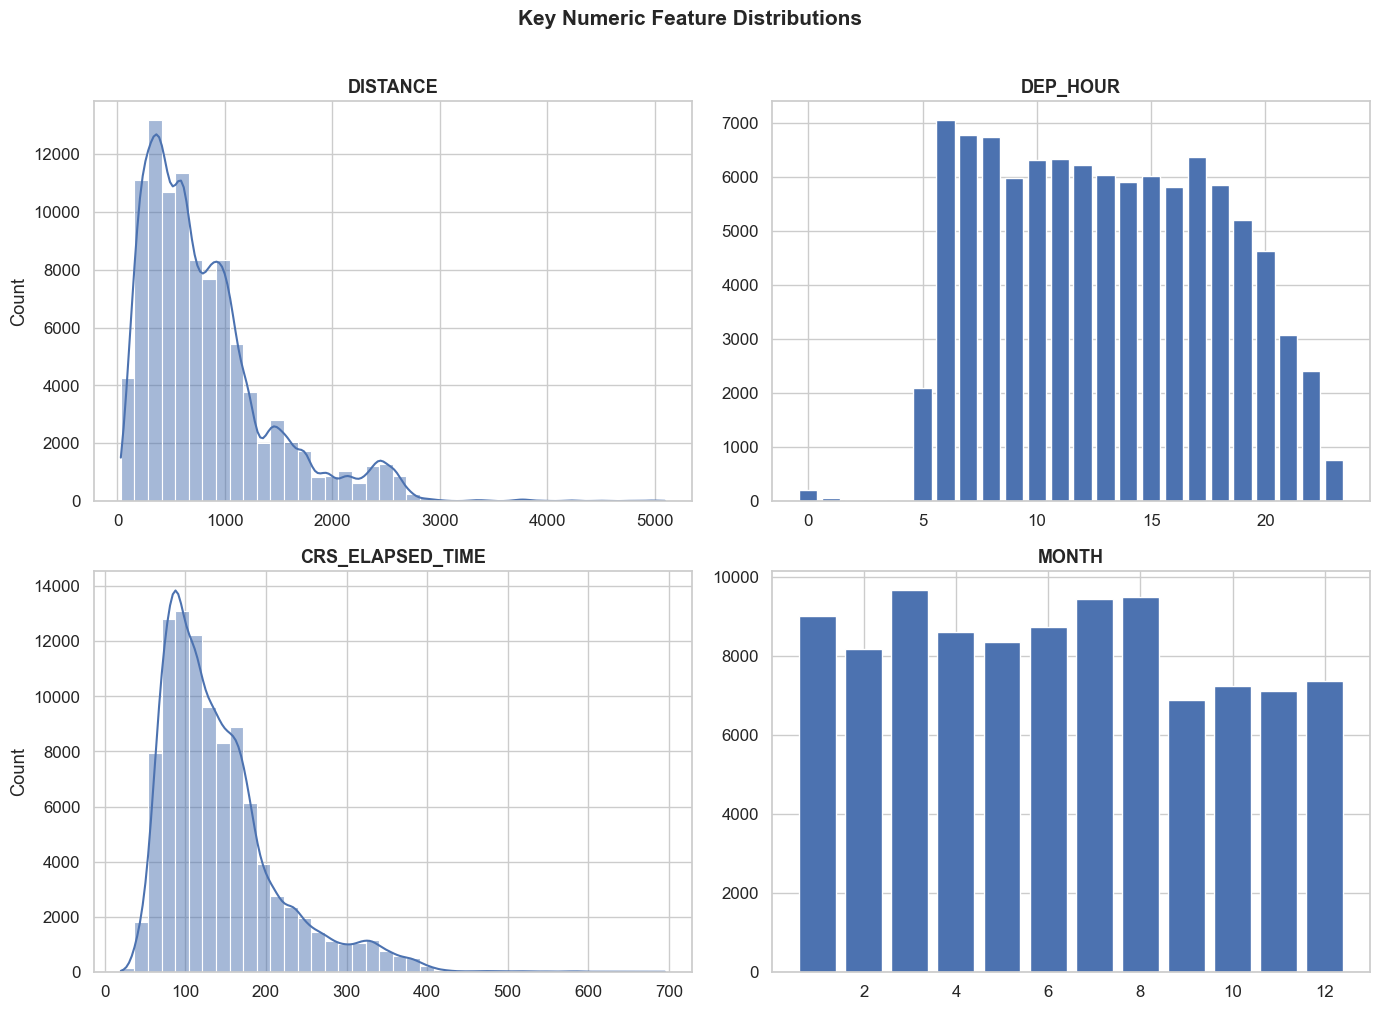

In [9]:
# Numeric feature distributions
df_plot = df.sample(100_000, random_state=42)

cols = ["DISTANCE", "DEP_HOUR", "CRS_ELAPSED_TIME", "MONTH"]
cols = [c for c in cols if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    if col in ["DISTANCE", "CRS_ELAPSED_TIME"]:
        sns.histplot(df_plot[col].dropna(), bins=40, kde=True, ax=ax,
                     color="#4C72B0", edgecolor="white")
    else:
        counts = df_plot[col].value_counts().sort_index()
        ax.bar(counts.index, counts.values, color="#4C72B0", edgecolor="white", width=0.8)
    ax.set_title(col, fontweight="bold", fontsize=13)
    ax.set_xlabel("")

fig.suptitle("Key Numeric Feature Distributions", fontweight="bold", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

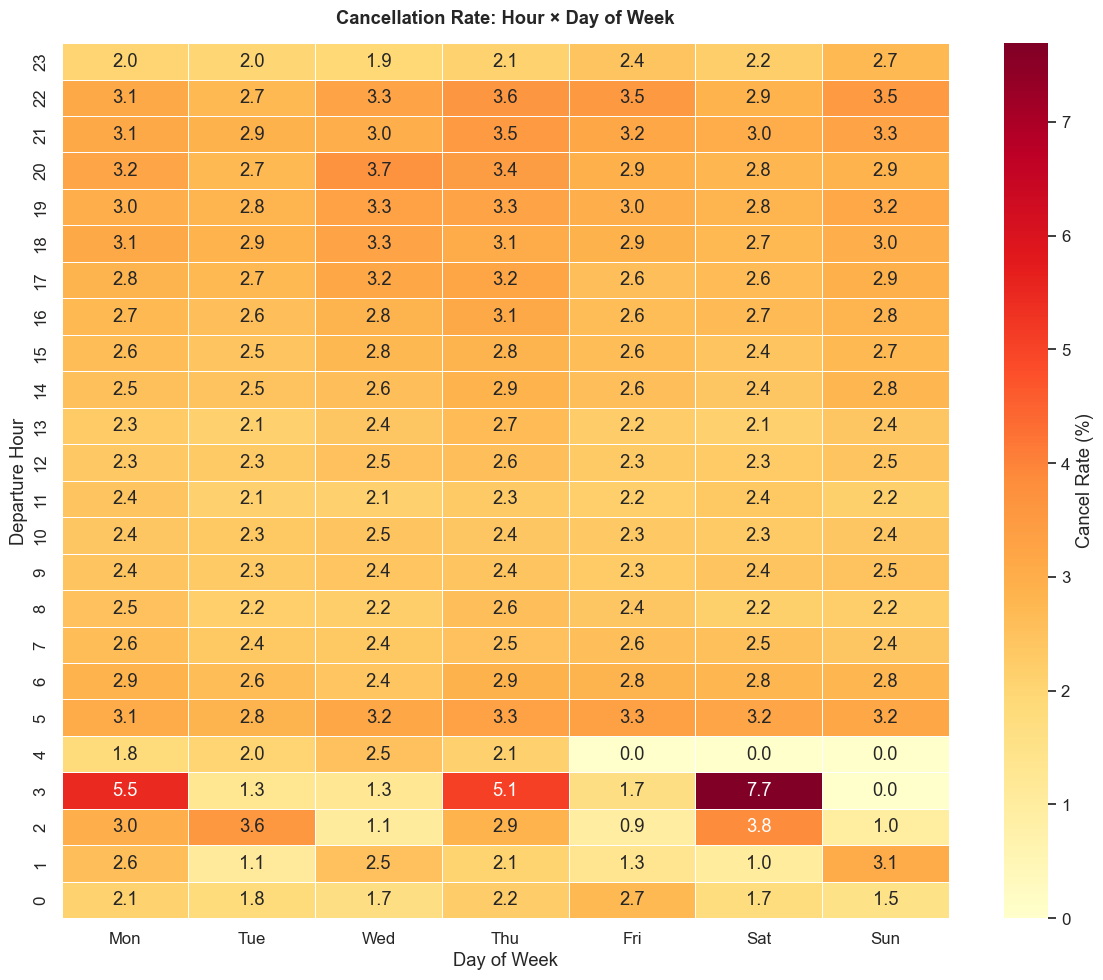

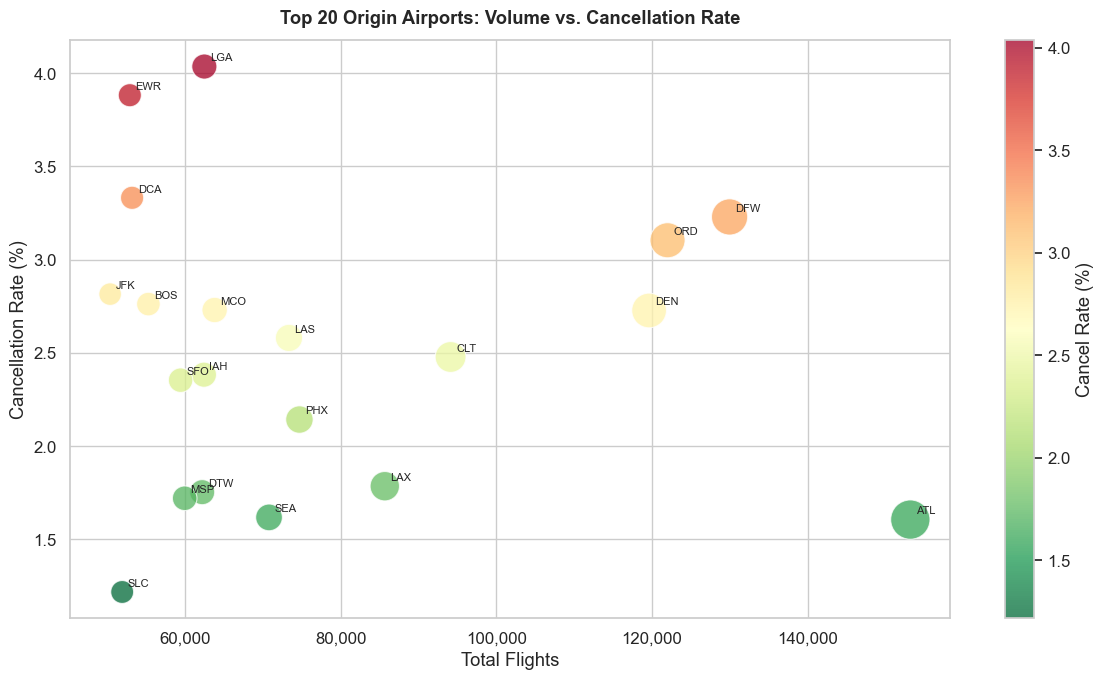

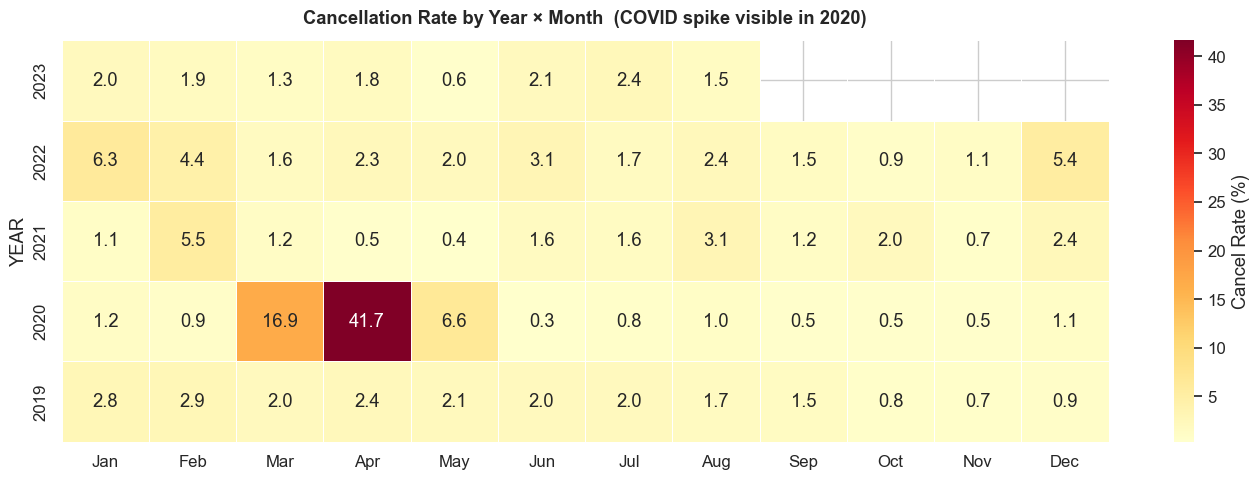

In [10]:
# Hour × Day-of-week Heatmap
pivot = (df.groupby(["DEP_HOUR", "DAY_OF_WEEK"])["CANCELLED"]
           .mean().mul(100).unstack("DAY_OF_WEEK"))
pivot.columns = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(pivot, ax=ax, cmap="YlOrRd", annot=True, fmt=".1f",
            linewidths=0.4, cbar_kws={"label": "Cancel Rate (%)"})
ax.invert_yaxis()
ax.set_title("Cancellation Rate: Hour × Day of Week", fontweight="bold", pad=14)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Departure Hour")
plt.tight_layout()
plt.show()

# Airport bubble chart
airport_stats = (df.groupby("ORIGIN")["CANCELLED"]
                   .agg(cancel_rate="mean", total="count")
                   .assign(cancel_rate=lambda x: x["cancel_rate"]*100)
                   .nlargest(20, "total"))

fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(airport_stats["total"], airport_stats["cancel_rate"],
                s=airport_stats["total"]/airport_stats["total"].max()*800,
                c=airport_stats["cancel_rate"], cmap="RdYlGn_r",
                alpha=0.75, edgecolors="white", linewidths=0.8)
for _, row in airport_stats.iterrows():
    ax.annotate(row.name, xy=(row["total"], row["cancel_rate"]),
                xytext=(4, 4), textcoords="offset points", fontsize=8)
plt.colorbar(sc, ax=ax, label="Cancel Rate (%)")
ax.set_title("Top 20 Origin Airports: Volume vs. Cancellation Rate", fontweight="bold", pad=12)
ax.set_xlabel("Total Flights")
ax.set_ylabel("Cancellation Rate (%)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

# Year × Month heatmap (COVID spike)
pivot = (df.groupby(["YEAR", "MONTH"])["CANCELLED"]
           .mean().mul(100).unstack("MONTH"))
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, ax=ax, cmap="YlOrRd", annot=True, fmt=".1f",
            linewidths=0.5, cbar_kws={"label": "Cancel Rate (%)"})
ax.invert_yaxis()
ax.set_title("Cancellation Rate by Year × Month  (COVID spike visible in 2020)",
             fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

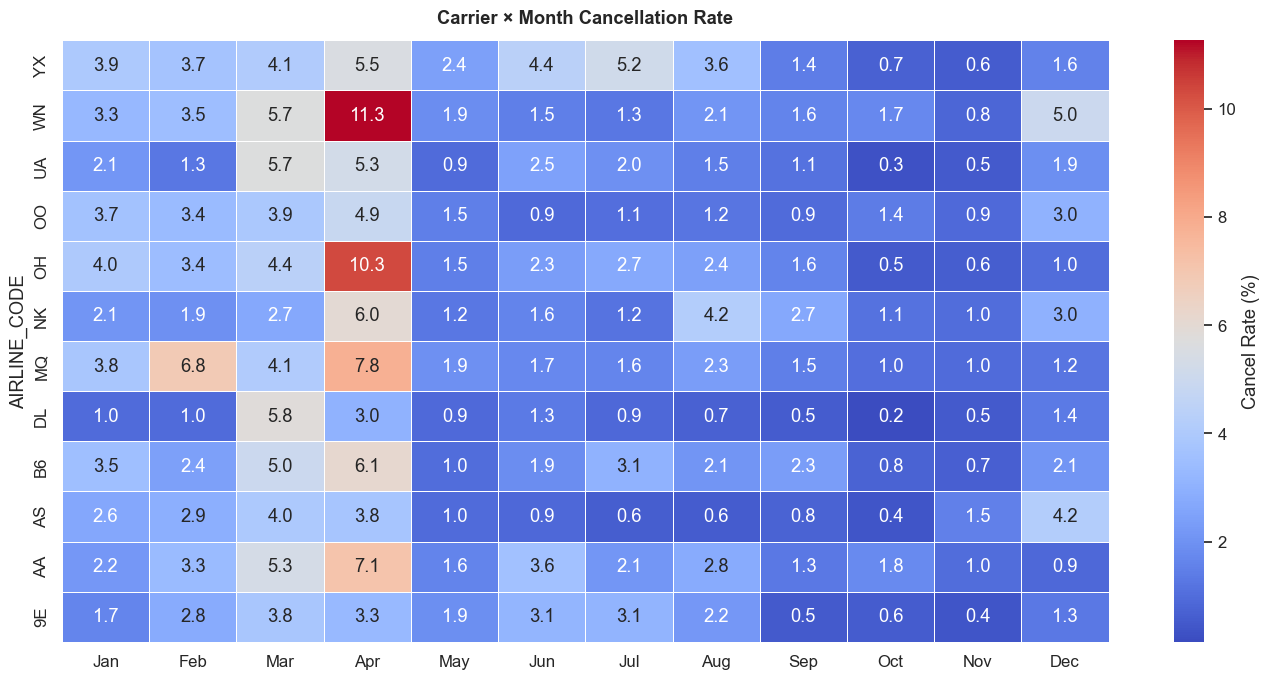

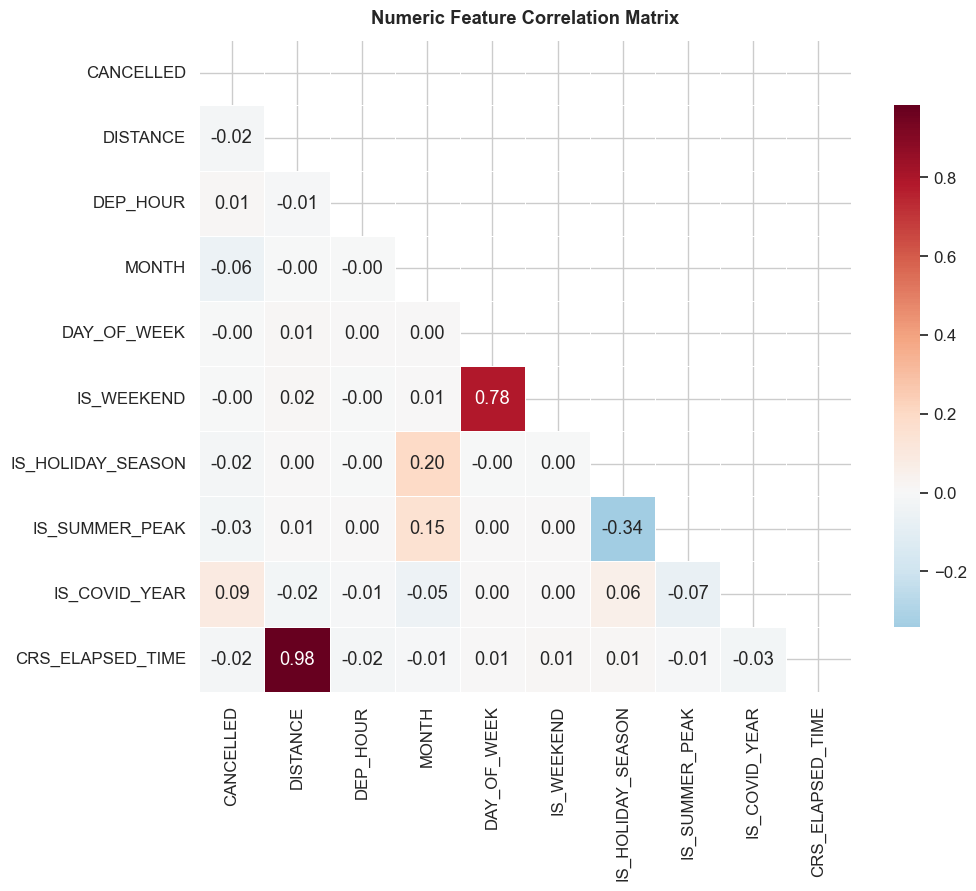

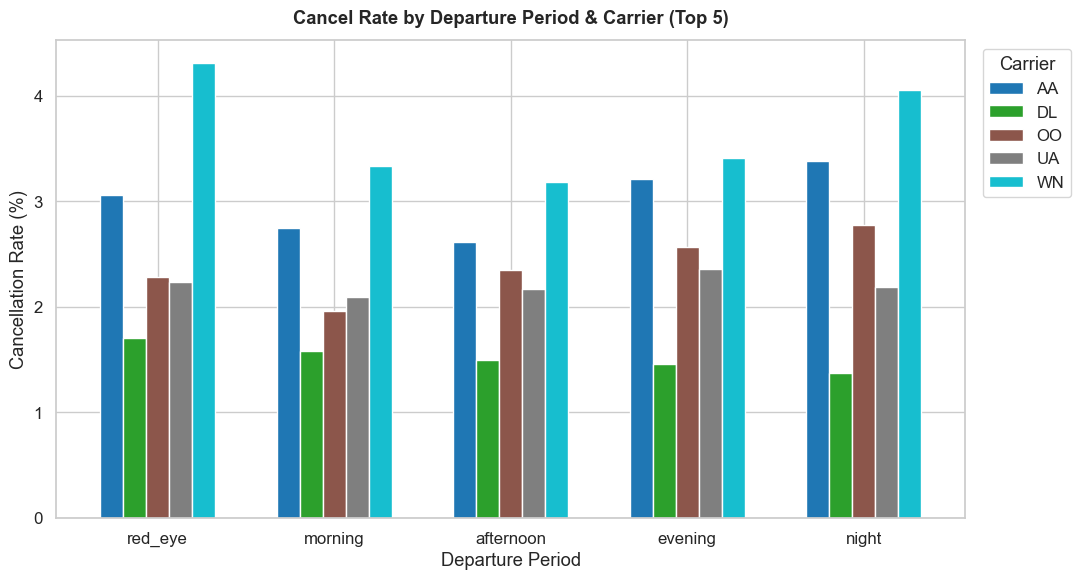

In [11]:
# Carrier × Month heatmap
top_carriers = df["AIRLINE_CODE"].value_counts().head(12).index
pivot = (df[df["AIRLINE_CODE"].isin(top_carriers)]
           .groupby(["AIRLINE_CODE", "MONTH"])["CANCELLED"]
           .mean().mul(100).unstack("MONTH"))
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot, ax=ax, cmap="coolwarm", annot=True, fmt=".1f",
            linewidths=0.4, cbar_kws={"label": "Cancel Rate (%)"})
ax.invert_yaxis()
ax.set_title("Carrier × Month Cancellation Rate", fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# Correlation matrix
num_cols = [c for c in [
    "CANCELLED", "DISTANCE", "DEP_HOUR", "MONTH", "DAY_OF_WEEK",
    "IS_WEEKEND", "IS_HOLIDAY_SEASON", "IS_SUMMER_PEAK", "IS_COVID_YEAR",
    "CRS_ELAPSED_TIME"
] if c in df.columns]
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, ax=ax, cmap="RdBu_r", center=0,
            annot=True, fmt=".2f", linewidths=0.5, square=True,
            cbar_kws={"shrink": 0.8})
ax.set_title("Numeric Feature Correlation Matrix", fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# Cancel rate by departure period × top-5 carriers
period_order = ["red_eye", "morning", "afternoon", "evening", "night"]
top5 = df["AIRLINE_CODE"].value_counts().head(5).index
pivot = (df[df["AIRLINE_CODE"].isin(top5)]
           .groupby(["DEP_PERIOD", "AIRLINE_CODE"])["CANCELLED"]
           .mean().mul(100).unstack("AIRLINE_CODE")
           .reindex(period_order))

fig, ax = plt.subplots(figsize=(11, 6))
pivot.plot(kind="bar", ax=ax, colormap="tab10", edgecolor="white", width=0.65)
ax.set_title("Cancel Rate by Departure Period & Carrier (Top 5)", fontweight="bold", pad=12)
ax.set_xlabel("Departure Period")
ax.set_ylabel("Cancellation Rate (%)")
ax.set_xticklabels(period_order, rotation=0)
ax.legend(title="Carrier", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Part 2. Modeling / AutoML / MLflow

In [ ]:
!pip install mlflow flaml scikit-learn joblib
!pip install "flaml[automl]"

In [15]:
import pandas as pd

print("正在准备 X_train 和 X_test...")

# 我们只丢弃 Target 变量，以及那些对机器学习没有直接帮助的冗余标识符
# 【注意】我们不再丢弃 'AIRLINE_CODE', 'ORIGIN', 'DEST', 'ROUTE', 'DEP_PERIOD'！
cols_to_drop = ['CANCELLED', 'FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'ORIGIN_CITY', 'DEST_CITY']

# 安全地提取特征 (X) 和 目标变量 (y)
cols_to_drop_train = [c for c in cols_to_drop if c in train.columns]
X_train = train.drop(columns=cols_to_drop_train)
y_train = train['CANCELLED']

cols_to_drop_test = [c for c in cols_to_drop if c in test.columns]
X_test = test.drop(columns=cols_to_drop_test)
y_test = test['CANCELLED']

print(f"✅ 数据准备完毕，完美衔接 Pipeline！")
print(f"X_train 维度: {X_train.shape}")
print(f"检查 X_train 是否包含必需列: {'AIRLINE_CODE' in X_train.columns}") 
# 这一行应该输出 True

正在准备 X_train 和 X_test...
✅ 数据准备完毕，完美衔接 Pipeline！
X_train 维度: (2530721, 21)
检查 X_train 是否包含必需列: True


In [13]:
import os
import json
import joblib
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import classification_report, precision_recall_curve, f1_score, roc_auc_score, average_precision_score
from flaml import AutoML

In [16]:
# ==========================================
# 0. 准备工作：定义特征列和目录
# ==========================================
# 创建 artifacts 文件夹供 Part 3 使用
os.makedirs("artifacts", exist_ok=True)

# 明确特征分类（请根据你实际的数据列名调整）
categorical_cols = ['AIRLINE_CODE', 'ORIGIN', 'DEST', 'ROUTE', 'DEP_PERIOD']
numeric_cols = ['DEP_HOUR', 'DEP_MIN', 'IS_WEEKEND', 'IS_HOLIDAY_SEASON', 'IS_SUMMER_PEAK', 'IS_COVID_YEAR']
feature_cols = categorical_cols + numeric_cols

# 确保数据只包含这些列
X_train = X_train[feature_cols]
X_test = X_test[feature_cols]

# ==========================================
# 1. 构建安全的 Preprocessing Pipeline
# ==========================================
print("正在构建安全的预处理 Pipeline...")
preprocessor = ColumnTransformer(
    transformers=[
        # 使用 OrdinalEncoder 并处理未见过的类别
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
    ],
    remainder='passthrough' # 数值列直接放行
)

# 转换数据供 FLAML 训练
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# ==========================================
# 2. 训练 AutoML (针对极度不平衡优化)
# ==========================================
mlflow.set_experiment("Flight_Cancellation_Production")

with mlflow.start_run(run_name="FLAML_Pipeline_Tuned"):
    print("\n--- 开始训练 FLAML (优化 PR-AUC) ---")
    automl = AutoML()
    automl_settings = {
        "time_budget": 300, 
        "metric": 'ap', # Average Precision (PR-AUC)，专治极端不平衡
        "task": 'classification',
        "eval_method": 'cv',
        "log_file_name": 'flaml_training.log',
        "seed": 42,
        "verbose": 0
    }
    
    # 可以在这里加入 sample_weight，或者让 LightGBM 自动处理类别不平衡
    automl.fit(X_train=X_train_proc, y_train=y_train, **automl_settings)
    
    # 提取底层最好的真实模型 (剥离 FLAML 的多线程外壳)
    best_estimator = automl.model.estimator
    
    # ==========================================
    # 3. 组装最终的端到端 Pipeline
    # ==========================================
    deploy_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', best_estimator)
    ])
    
    # ==========================================
    # 4. 寻找最佳预测阈值 (Threshold Tuning)
    # ==========================================
    print("\n--- 正在寻找最佳分类阈值 ---")
    # 注意：这里我们直接用 deploy_pipeline 进行预测，验证 Pipeline 完整性
    y_prob_test = deploy_pipeline.predict_proba(X_test)[:, 1]
    
    # 计算 Precision-Recall 曲线
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_test)
    
    # 计算所有阈值下的 F1 Score
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[best_idx]
    
    print(f"默认 0.5 阈值的 F1 Score: {f1_score(y_test, y_prob_test >= 0.5):.4f}")
    print(f"最佳阈值 (Optimal Threshold): {optimal_threshold:.4f}")
    print(f"最佳阈值下的 F1 Score: {f1_scores[best_idx]:.4f}")
    
    # 使用最佳阈值生成最终预测
    y_pred_optimal = (y_prob_test >= optimal_threshold).astype(int)
    
    # 记录 Metrics 到 MLflow
    metrics = {
        "roc_auc": roc_auc_score(y_test, y_prob_test),
        "pr_auc": average_precision_score(y_test, y_prob_test),
        "optimal_threshold": optimal_threshold,
        "f1_optimal": f1_scores[best_idx]
    }
    mlflow.log_metrics(metrics)
    
    print("\n--- 最终模型表现 (基于最佳阈值) ---")
    print(classification_report(y_test, y_pred_optimal))

    # ==========================================
    # 5. 导出 Artifacts 供 Part 3 部署
    # ==========================================
    # 保存完整的 Pipeline (预处理 + 模型)
    pipeline_path = "artifacts/model_pipeline.pkl"
    joblib.dump(deploy_pipeline, pipeline_path)
    mlflow.log_artifact(pipeline_path)
    
    # 保存特征列配置和最佳阈值，FastAPI 直接读取
    config_data = {
        "feature_columns": feature_cols,
        "categorical_columns": categorical_cols,
        "numeric_columns": numeric_cols,
        "optimal_threshold": float(optimal_threshold)
    }
    config_path = "artifacts/model_config.json"
    with open(config_path, "w") as f:
        json.dump(config_data, f, indent=4)
    mlflow.log_artifact(config_path)

print(f"\n✅ 训练与打包完成！")
print(f"请将整个 'artifacts/' 文件夹交给负责 Part 3 的同学！")

正在构建安全的预处理 Pipeline...


2026/05/26 19:25:08 INFO mlflow.tracking.fluent: Experiment with name 'Flight_Cancellation_Production' does not exist. Creating a new experiment.



--- 开始训练 FLAML (优化 PR-AUC) ---

--- 正在寻找最佳分类阈值 ---
默认 0.5 阈值的 F1 Score: 0.0000
最佳阈值 (Optimal Threshold): 0.0523
最佳阈值下的 F1 Score: 0.0847

--- 最终模型表现 (基于最佳阈值) ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    454414
           1       0.11      0.07      0.08      7809

    accuracy                           0.97    462223
   macro avg       0.55      0.53      0.54    462223
weighted avg       0.97      0.97      0.97    462223


✅ 训练与打包完成！
请将整个 'artifacts/' 文件夹交给负责 Part 3 的同学！
